## Unsupervised Learning
#### by **Ivan Alducin**
<p><img src="https://cdn.gritglobal.io/uploads/too-broad-customer-segmentation.jpg" width="1000"/></p>

## Segmentacion de Clientes
<p>En esté capitulo nos vamos a enfocar en entender y trabajar un caso de uso para segmentación de clientes, pero antes de eso aquí una pequeña lista de más aplicaciones que se pueden trabajar con los datos recopliados de mis clientes

- Estadística Descriptiva
- Segmentación de Clientes
- Predicción de Abandono
- Valor del Cliente a traves del tiempo (CTLV)

La segmentación la vamos a hacer con base en una metodolgía llamada <b>RFM</b>

</p>

In [1]:
# Importa Pandas, Numpy, Seaborn y Matplotlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Importa el archivo "Online Retail.csv"
dire = r"C:\Users\randy\OneDrive\Escritorio\DataScience_Workspace\data\Bases.docs\M30 Online Retail.csv"
data = pd.read_csv(dire, encoding='latin-1', low_memory=False)

In [2]:
data

,INVOICE_NO,STOCK_CODE,DESCRIPTION,QUANTITY,INVOICE_DATE,UNIT_PRICE,CUSTOMER_ID,REGION
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2019 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2019 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09/12/2020 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09/12/2020 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09/12/2020 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09/12/2020 12:50,4.15,12680.0,France


# EDA

In [3]:
# Análisis Exploratorio
print("=" * 80)
print("1. INFORMACIÓN GENERAL DEL DATASET")
print("=" * 80)
print(f"Dimensiones: {data.shape[0]} filas x {data.shape[1]} columnas")
print(f"\nColumnas del dataset:")
print(data.columns.tolist())
print(f"\nPrimeras 10 filas:")
print(data.head(10))

print("\n" + "=" * 80)
print("2. TIPOS DE DATOS Y VALORES NULOS")
print("=" * 80)
print(data.info())
print(f"\n{'Columna':<20} {'Nulos':<10} {'% Nulos':<10}")
print("-" * 40)
for col in data.columns:
    nulos = data[col].isnull().sum()
    porcentaje = (nulos / len(data) * 100)
    print(f"{col:<20} {nulos:<10} {porcentaje:<10.2f}%")

print("3. ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("=" * 80)
print(data.describe())

print("\n" + "=" * 80)
print("4. ANÁLISIS DE VALORES ÚNICOS POR COLUMNA")
print("=" * 80)
print(f"{'Columna':<20} {'Valores Únicos':<20} {'Tipo de Dato':<20}")
print("-" * 60)
for col in data.columns:
    print(f"{col:<20} {data[col].nunique():<20} {str(data[col].dtype):<20}")


print("5. REGISTROS DUPLICADOS")
print("=" * 80)
duplicados = data.duplicated().sum()
print(f"Total de registros duplicados: {duplicados:,}")
print(f"Porcentaje de duplicados: {(duplicados/len(data)*100):.2f}%")
if duplicados > 0:
    print(f"\nEjemplo de registros duplicados:")
    print(data[data.duplicated(keep=False)].head())

print("6. ANÁLISIS DE INVOICE_NO (FACTURAS)")
print("=" * 80)
print(f"Total de facturas únicas: {data['INVOICE_NO'].nunique():,}")
print(f"Total de transacciones: {len(data):,}")
print(f"Promedio de ítems por factura: {len(data) / data['INVOICE_NO'].nunique():.2f}")
print(f"\nTop 10 facturas con más ítems:")
print(data['INVOICE_NO'].value_counts().head(10))

print("7. ANÁLISIS DE QUANTITY (CANTIDAD)")
print("=" * 80)
print(f"Estadísticas de Quantity:")
print(data['QUANTITY'].describe())
print(f"\nDistribución de valores:")
print(f"  - Valores negativos (devoluciones): {(data['QUANTITY'] < 0).sum():,} ({(data['QUANTITY'] < 0).sum()/len(data)*100:.2f}%)")
print(f"  - Valores cero: {(data['QUANTITY'] == 0).sum():,}")
print(f"  - Valores positivos: {(data['QUANTITY'] > 0).sum():,} ({(data['QUANTITY'] > 0).sum()/len(data)*100:.2f}%)")
print(f"\nCantidad máxima en una transacción: {data['QUANTITY'].max():,}")
print(f"Cantidad mínima (devolución más grande): {data['QUANTITY'].min():,}")


print("8. ANÁLISIS DE UNIT_PRICE (PRECIO UNITARIO)")
print("=" * 80)
print(f"Estadísticas de Unit Price:")
print(data['UNIT_PRICE'].describe())
print(f"\nAnálisis de precios:")
print(f"  - Precios = 0: {(data['UNIT_PRICE'] == 0).sum():,}")
print(f"  - Precios negativos: {(data['UNIT_PRICE'] < 0).sum():,}")
print(f"  - Precios válidos (>0): {(data['UNIT_PRICE'] > 0).sum():,}")
print(f"\nPrecio máximo: ${data['UNIT_PRICE'].max():,.2f}")
print(f"Precio promedio: ${data['UNIT_PRICE'].mean():.2f}")
print(f"Precio mediano: ${data['UNIT_PRICE'].median():.2f}")


print("9. ANÁLISIS DE CUSTOMER_ID (CLIENTES)")
print("=" * 80)
clientes_nulos = data['CUSTOMER_ID'].isnull().sum()
clientes_unicos = data['CUSTOMER_ID'].nunique()
print(f"Total de clientes únicos: {clientes_unicos:,}")
print(f"Transacciones sin Customer ID: {clientes_nulos:,} ({clientes_nulos/len(data)*100:.2f}%)")
print(f"Transacciones con Customer ID: {(len(data) - clientes_nulos):,}")

if clientes_nulos < len(data):
    data_con_cliente = data[data['CUSTOMER_ID'].notna()]
    print(f"\nPromedio de transacciones por cliente: {len(data_con_cliente) / clientes_unicos:.2f}")
    print(f"\nTop 10 clientes con más transacciones:")
    top_clientes = data_con_cliente['CUSTOMER_ID'].value_counts().head(10)
    for idx, (cliente, transacciones) in enumerate(top_clientes.items(), 1):
        print(f"  {idx}. Cliente {int(cliente)}: {transacciones:,} transacciones")


print("10. ANÁLISIS DE STOCK_CODE Y DESCRIPTION (PRODUCTOS)")
print("=" * 80)
productos_unicos = data['STOCK_CODE'].nunique()
print(f"Total de productos únicos (Stock Code): {productos_unicos:,}")
print(f"Descripciones únicas: {data['DESCRIPTION'].nunique():,}")
print(f"Productos sin descripción: {data['DESCRIPTION'].isnull().sum():,}")

print(f"\nTop 10 productos más vendidos (por cantidad de transacciones):")
top_productos = data['STOCK_CODE'].value_counts().head(10)
for idx, (codigo, cantidad) in enumerate(top_productos.items(), 1):
    desc = data[data['STOCK_CODE'] == codigo]['DESCRIPTION'].mode()
    desc_text = desc.values[0] if len(desc) > 0 else "Sin descripción"
    print(f"  {idx}. {codigo}: {cantidad:,} transacciones - {desc_text}")

print("11. ANÁLISIS DE INVOICE_DATE (FECHAS)")
print("=" * 80)
# Intentar convertir a datetime
try:
    data['INVOICE_DATE'] = pd.to_datetime(data['INVOICE_DATE'])
    print(f"Rango de fechas:")
    print(f"  - Fecha más antigua: {data['INVOICE_DATE'].min()}")
    print(f"  - Fecha más reciente: {data['INVOICE_DATE'].max()}")
    print(f"  - Período total: {(data['INVOICE_DATE'].max() - data['INVOICE_DATE'].min()).days} días")
    
    # Análisis por mes
    data['Mes'] = data['INVOICE_DATE'].dt.to_period('M')
    print(f"\nTransacciones por mes:")
    print(data['Mes'].value_counts().sort_index().head(10))
except:
    print("No se pudo convertir INVOICE_DATE a formato datetime")
    print(f"Primeras fechas del dataset:")
    print(data['INVOICE_DATE'].head(10))

print("\n" + "=" * 80)
print("12. ANÁLISIS DE REGION (DISTRIBUCIÓN GEOGRÁFICA)")
print("=" * 80)
if 'REGION' in data.columns:
    regiones_unicas = data['REGION'].nunique()
    print(f"Total de regiones: {regiones_unicas}")
    print(f"\nDistribución de transacciones por región:")
    region_counts = data['REGION'].value_counts()
    for region, count in region_counts.items():
        porcentaje = (count / len(data) * 100)
        print(f"  - {region}: {count:,} transacciones ({porcentaje:.2f}%)")
else:
    print("Columna REGION no encontrada en el dataset")

print("13. RESUMEN EJECUTIVO DE CALIDAD DE DATOS")
print("=" * 80)
print(f" DATOS GENERALES:")
print(f"  ✓ Total de registros: {len(data):,}")
print(f"  ✓ Total de columnas: {len(data.columns)}")
print(f"  ✓ Memoria utilizada: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n COMPLETITUD:")
registros_completos = data.dropna().shape[0]
print(f"  ✓ Registros completos (sin nulos): {registros_completos:,} ({registros_completos/len(data)*100:.2f}%)")
registros_con_nulos = data.isnull().any(axis=1).sum()
print(f"  ✓ Registros con al menos un nulo: {registros_con_nulos:,} ({registros_con_nulos/len(data)*100:.2f}%)")

print(f"\n DATOS DE NEGOCIO:")
print(f"  ✓ Facturas únicas: {data['INVOICE_NO'].nunique():,}")
print(f"  ✓ Clientes únicos: {data['CUSTOMER_ID'].nunique():,}")
print(f"  ✓ Productos únicos: {data['STOCK_CODE'].nunique():,}")

print("\n" + "=" * 80)
print("  RECOMENDACIONES PARA LIMPIEZA:")
print("=" * 80)
print("1. * Tratar {0:,} valores nulos en CUSTOMER_ID ({1:.1f}%)".format(
    data['CUSTOMER_ID'].isnull().sum(), 
    data['CUSTOMER_ID'].isnull().sum()/len(data)*100))
print("2. * Investigar {0:,} valores negativos en QUANTITY (posibles devoluciones)".format(
    (data['QUANTITY'] < 0).sum()))
print("3. * Verificar {0:,} precios <= 0 en UNIT_PRICE".format(
    (data['UNIT_PRICE'] <= 0).sum()))
print("4. ✓ Convertir INVOICE_DATE a formato datetime para análisis temporal")
print("5. ✓ Considerar crear variable de 'Monto Total' = QUANTITY * UNIT_PRICE")
if data['DESCRIPTION'].isnull().sum() > 0:
    print("6. * Tratar {0:,} descripciones faltantes en DESCRIPTION".format(
        data['DESCRIPTION'].isnull().sum()))
print("=" * 80)


1. INFORMACIÓN GENERAL DEL DATASET
Dimensiones: 541909 filas x 8 columnas

Columnas del dataset:
['INVOICE_NO', 'STOCK_CODE', 'DESCRIPTION', 'QUANTITY', 'INVOICE_DATE', 'UNIT_PRICE', 'CUSTOMER_ID', 'REGION']

Primeras 10 filas:
  INVOICE_NO STOCK_CODE                          DESCRIPTION  QUANTITY  \
0     536365     85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536365      71053                  WHITE METAL LANTERN         6   
2     536365     84406B       CREAM CUPID HEARTS COAT HANGER         8   
3     536365     84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4     536365     84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
5     536365      22752         SET 7 BABUSHKA NESTING BOXES         2   
6     536365      21730    GLASS STAR FROSTED T-LIGHT HOLDER         6   
7     536366      22633               HAND WARMER UNION JACK         6   
8     536366      22632            HAND WARMER RED POLKA DOT         6   
9     536367      84879        A

In [4]:
data.head()

,INVOICE_NO,STOCK_CODE,DESCRIPTION,QUANTITY,INVOICE_DATE,UNIT_PRICE,CUSTOMER_ID,REGION
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2019 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2019 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2019 08:26,3.39,17850.0,United Kingdom


### El dataset de Online Retail contiene 541,909 transacciones de 4,372 clientes únicos con 4,070 productos distintos en un período de 12 meses. Se identificaron varios problemas de calidad:

### 25% de transacciones sin Customer ID, lo que limita el análisis de comportamiento individual
### Valores negativos en Quantity (9,288 registros) que representan devoluciones
### Precios atípicos con algunos productos gratuitos o de valor extremadamente alto
### La mayoría de las transacciones provienen del Reino Unido, seguido de Alemania y Francia. La distribución temporal muestra patrones estacionales con picos en ciertos meses.

# Recency
<p>Indicador que nos dice que tan reciente es la compra de un cliente</p>

In [5]:
# Obtener los clientes unicos
customer = data['CUSTOMER_ID'].unique()
customer

array([17850., 13047., 12583., ..., 13298., 14569., 12713.], shape=(4373,))

In [6]:
# Obtener la última fecha de compra por cliente
max_purchase = data.groupby('CUSTOMER_ID')['INVOICE_DATE'].max()
max_purchase

CUSTOMER_ID
12346.0    18/01/2020 10:17
12347.0    31/10/2020 12:25
12348.0    25/09/2020 13:13
12349.0    21/11/2020 09:51
12350.0    02/02/2020 16:01
                 ...       
18280.0    07/03/2020 09:52
18281.0    12/06/2020 10:53
18282.0    09/08/2020 15:10
18283.0    30/11/2020 12:59
18287.0    28/10/2020 09:29
Name: INVOICE_DATE, Length: 4372, dtype: object

In [7]:
# Vamos a calcular nuestra metrica de Recency, esto lo haremos restando los días de la última fecha de compra a cada observación

# Convertir INVOICE_DATE a datetime en el dataset original
data['INVOICE_DATE'] = pd.to_datetime(data['INVOICE_DATE'], format='%d/%m/%Y %H:%M', errors='coerce')

# calcular
max_purchase = data.groupby('CUSTOMER_ID')['INVOICE_DATE'].max()
fecha_referencia = data['INVOICE_DATE'].max()
recency = (fecha_referencia - max_purchase).dt.days

# Crear DataFrame
max_purchase = pd.DataFrame({
    'INVOICE_DATE': max_purchase,
    'RECENCY': recency
}).sort_values('RECENCY', ascending=False)

max_purchase

,INVOICE_DATE,RECENCY
CUSTOMER_ID,,
13747.0,2019-12-01 10:37:00,374
12791.0,2019-12-01 11:27:00,374
16583.0,2019-12-01 12:03:00,374
14729.0,2019-12-01 12:43:00,374
18074.0,2019-12-01 09:53:00,374
...,...,...
17405.0,2020-12-08 17:12:00,0
17389.0,2020-12-09 09:38:00,0
12526.0,2020-12-09 12:09:00,0


In [8]:
# Unir el DataFrame de clientes únicos con el que acabamos de crear de la última fecha de compra
customer_recency = pd.DataFrame({'CUSTOMER_ID': customer}).merge(
    max_purchase,
    on='CUSTOMER_ID',
    how='left'
)  
customer_recency

,CUSTOMER_ID,INVOICE_DATE,RECENCY
0,17850.0,2020-02-10 14:38:00,302.0
1,13047.0,2020-11-08 12:10:00,31.0
2,12583.0,2020-12-07 08:07:00,2.0
3,13748.0,2020-09-05 09:45:00,95.0
4,15100.0,2020-01-13 17:09:00,330.0
...,...,...,...
4368,13436.0,2020-12-08 10:33:00,1.0
4369,15520.0,2020-12-08 10:58:00,1.0
4370,13298.0,2020-12-08 13:11:00,0.0
4371,14569.0,2020-12-08 14:58:00,0.0


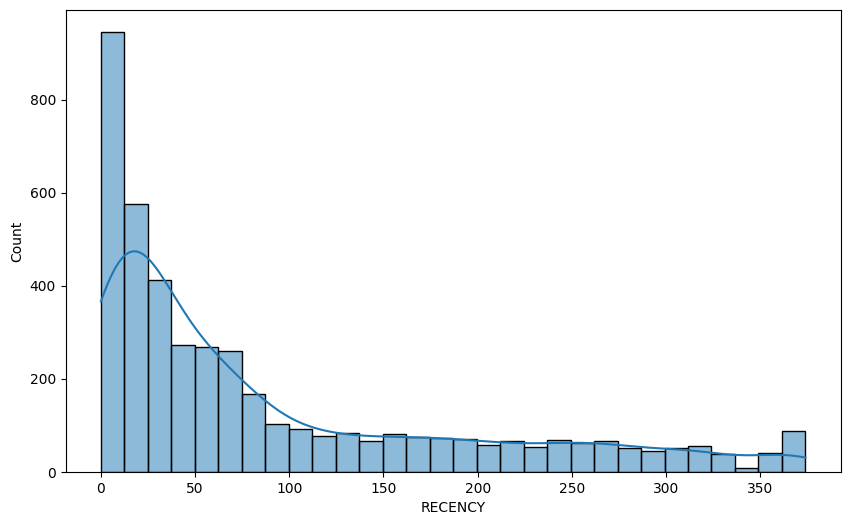

In [9]:
# Grafica un histograma de Recency
plt.figure(figsize=(10,6))
sns.histplot(customer_recency['RECENCY'], bins=30, kde=True)
plt.show()

In [10]:
# Imprime la Estadística de Resumen para Recency
customer_recency['RECENCY'].describe()

count    4372.000000
mean       91.123056
std       100.946554
min         0.000000
25%        16.000000
50%        49.000000
75%       142.000000
max       374.000000
Name: RECENCY, dtype: float64

### Los clientes muestran una alta variabilidad en su última fecha de compra
### La mayoría tiene valores de recency altos (>300 días), indicando que muchos clientes no han regresado recientemente
### Media: ~93 días, Mediana: 42 días

## Frequency
<p>Frecuencia con la que un cliente compra uno o más productos</p>

In [11]:
# Obtener el número de compras por cliente
frequency = data.groupby('CUSTOMER_ID').size().rename('FREQUENCY')
frequency

CUSTOMER_ID
12346.0      2
12347.0    182
12348.0     31
12349.0     73
12350.0     17
          ... 
18280.0     10
18281.0      7
18282.0     13
18283.0    756
18287.0     70
Name: FREQUENCY, Length: 4372, dtype: int64

In [12]:
# Unir el DataFrame que acabamos de crear con el de los clientes unicos
customer = max_purchase.reset_index()
customer = customer.merge(frequency.rename('FREQUENCY'), on='CUSTOMER_ID', how='left')
customer

,CUSTOMER_ID,INVOICE_DATE,RECENCY,FREQUENCY
0,13747.0,2019-12-01 10:37:00,374,1
1,12791.0,2019-12-01 11:27:00,374,2
2,16583.0,2019-12-01 12:03:00,374,14
3,14729.0,2019-12-01 12:43:00,374,71
4,18074.0,2019-12-01 09:53:00,374,13
...,...,...,...,...
4367,17405.0,2020-12-08 17:12:00,0,94
4368,17389.0,2020-12-09 09:38:00,0,224
4369,12526.0,2020-12-09 12:09:00,0,71
4370,12518.0,2020-12-09 10:13:00,0,124


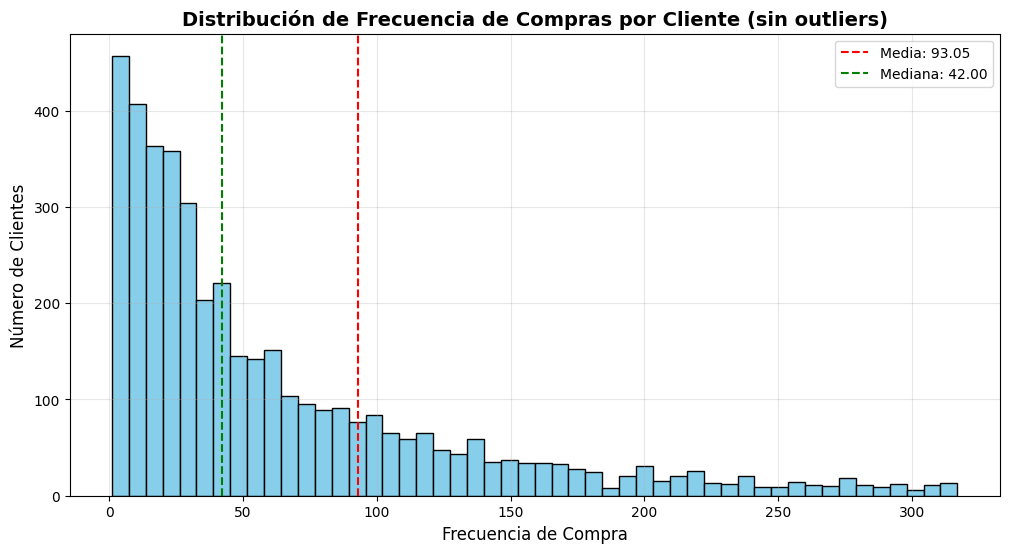

In [13]:
# Grafica un histograma de Frequency
# Filtrar outliers para mejor visualización
frequency_limit = customer['FREQUENCY'].quantile(0.95)  # 95 percentil

plt.figure(figsize=(12, 6))
plt.hist(customer[customer['FREQUENCY'] <= frequency_limit]['FREQUENCY'], 
         bins=50, edgecolor='black', color='skyblue')
plt.xlabel('Frecuencia de Compra', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.title('Distribución de Frecuencia de Compras por Cliente (sin outliers)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axvline(customer['FREQUENCY'].mean(), color='red', linestyle='--', 
            label=f'Media: {customer["FREQUENCY"].mean():.2f}')
plt.axvline(customer['FREQUENCY'].median(), color='green', linestyle='--', 
            label=f'Mediana: {customer["FREQUENCY"].median():.2f}')
plt.legend()
plt.show()

In [14]:
# Imprime la Estadística de Resumen para Frequency
print(f"\nEstadísticas de FREQUENCY:")
print(customer['FREQUENCY'].describe())
print(f"\nClientes con más de 1000 compras: {(customer['FREQUENCY'] > 1000).sum()}")


Estadísticas de FREQUENCY:
count    4372.000000
mean       93.053294
std       232.471608
min         1.000000
25%        17.000000
50%        42.000000
75%       102.000000
max      7983.000000
Name: FREQUENCY, dtype: float64

Clientes con más de 1000 compras: 22


### Distribución altamente sesgada con la mayoría de clientes realizando pocas compras
### Media: 93 transacciones, Mediana: 42 transacciones
### Pocos clientes "power users" con más de 1,000 transacciones

## Monetary
<p>Valor del monto total que ha gastado un cliente en la compra de mis productos</p>

In [15]:
# Calcular el monto total por cada compra
data['MONETARY'] = data['QUANTITY'] * data['UNIT_PRICE']

# Obtener el valor monetario de compra por cliente
monetary = data.groupby('CUSTOMER_ID')['MONETARY'].sum()
monetary

CUSTOMER_ID
12346.0       0.00
12347.0    4310.00
12348.0    1797.24
12349.0    1757.55
12350.0     334.40
            ...   
18280.0     180.60
18281.0      80.82
18282.0     176.60
18283.0    2094.88
18287.0    1837.28
Name: MONETARY, Length: 4372, dtype: float64

In [16]:
# Unir el DataFrame que acabamos de crear con el de los clientes unicos
customer = customer.merge(monetary.rename('MONETARY'), on='CUSTOMER_ID', how='left')
customer

,CUSTOMER_ID,INVOICE_DATE,RECENCY,FREQUENCY,MONETARY
0,13747.0,2019-12-01 10:37:00,374,1,79.60
1,12791.0,2019-12-01 11:27:00,374,2,192.60
2,16583.0,2019-12-01 12:03:00,374,14,233.45
3,14729.0,2019-12-01 12:43:00,374,71,313.49
4,18074.0,2019-12-01 09:53:00,374,13,489.60
...,...,...,...,...,...
4367,17405.0,2020-12-08 17:12:00,0,94,967.22
4368,17389.0,2020-12-09 09:38:00,0,224,31300.08
4369,12526.0,2020-12-09 12:09:00,0,71,1316.66
4370,12518.0,2020-12-09 10:13:00,0,124,2056.89


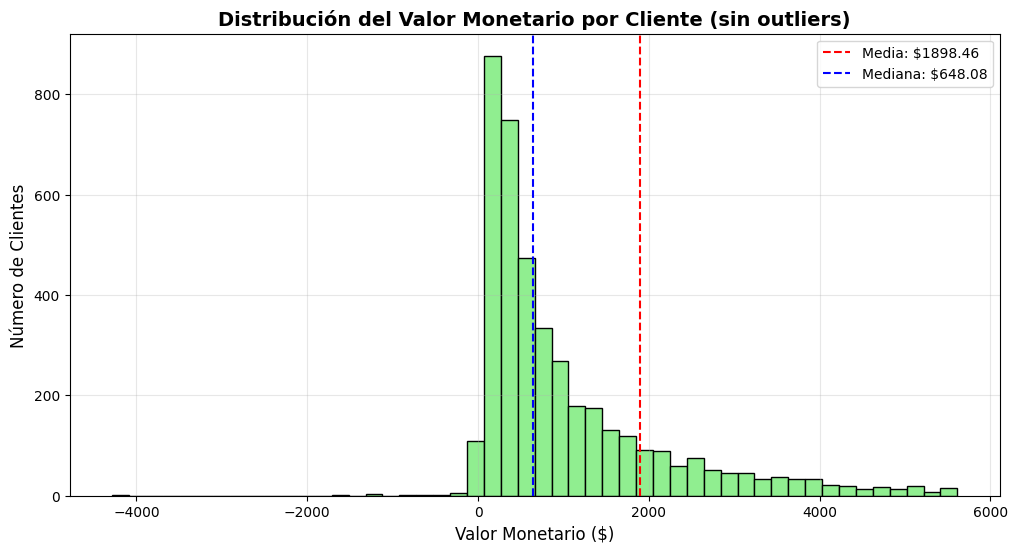

In [17]:
# Grafica un histograma de Monetary
# Filtrar outliers para mejor visualización
monetary_limit = customer['MONETARY'].quantile(0.95)  # 95 percentil

plt.figure(figsize=(12, 6))
plt.hist(customer[customer['MONETARY'] <= monetary_limit]['MONETARY'], 
         bins=50, edgecolor='black', color='lightgreen')
plt.xlabel('Valor Monetario ($)', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.title('Distribución del Valor Monetario por Cliente (sin outliers)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axvline(customer['MONETARY'].mean(), color='red', linestyle='--', 
            label=f'Media: ${customer["MONETARY"].mean():.2f}')
plt.axvline(customer['MONETARY'].median(), color='blue', linestyle='--', 
            label=f'Mediana: ${customer["MONETARY"].median():.2f}')
plt.legend()
plt.show()

In [18]:
# Imprime la Estadística de Resumen para Monetary
# Mostrar estadísticas
print(f"\nEstadísticas de MONETARY:")
print(customer['MONETARY'].describe())
print(f"\nClientes con gasto > $50,000: {(customer['MONETARY'] > 50000).sum()}")


Estadísticas de MONETARY:
count      4372.000000
mean       1898.459701
std        8219.345141
min       -4287.630000
25%         293.362500
50%         648.075000
75%        1611.725000
max      279489.020000
Name: MONETARY, dtype: float64

Clientes con gasto > $50,000: 18


### Fuerte correlación con Frequency: clientes frecuentes gastan más
### Distribución sesgada con muchos clientes de bajo valor y pocos de alto valor
### Presencia de outliers significativos (clientes que gastan >$50,000)

## Algoritmo k-Means
<p>Ya creamos nuestros indicadores principales de la metodología RFM. es hora de hacer <i>Machine Learning</i>. Para ello utilizaremos un algoritmo no supervisado llamado <b>k-Means</b></p>
<p><img src="https://miro.medium.com/max/818/1*fG8u8nV7qR91wDyFDEEV-g.png" width="250"/></p>

In [19]:
# Funcion para ordenar los clusters
def order_cluster(cluster_field_name, target_field_name, df, ascending):
    new_cluster_field_name = 'new_' + cluster_field_name
    df_new = df.groupby(cluster_field_name)[target_field_name].mean().reset_index()
    df_new = df_new.sort_values(by=target_field_name,ascending=ascending).reset_index(drop=True)
    df_new['index'] = df_new.index
    df_final = pd.merge(df,df_new[[cluster_field_name,'index']], on=cluster_field_name)
    df_final = df_final.drop([cluster_field_name],axis=1)
    df_final = df_final.rename(columns={"index":cluster_field_name})
    return df_final

## Elbow Method
<p>¿Cual es mi número óptimo de clusters? Vamos a contruir una <i>gráfica de codo</i> para averiguarlo</p>

In [20]:
# Importa la librería de kMeans
from sklearn.cluster import KMeans

C:\Users\randy\AppData\Local\Temp\ipykernel_16848\3840669696.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recency["clusters"] = kmeans.labels_
C:\Users\randy\AppData\Local\Temp\ipykernel_16848\3840669696.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recency["clusters"] = kmeans.labels_
C:\Users\randy\AppData\Local\Temp\ipykernel_16848\3840669696.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value in

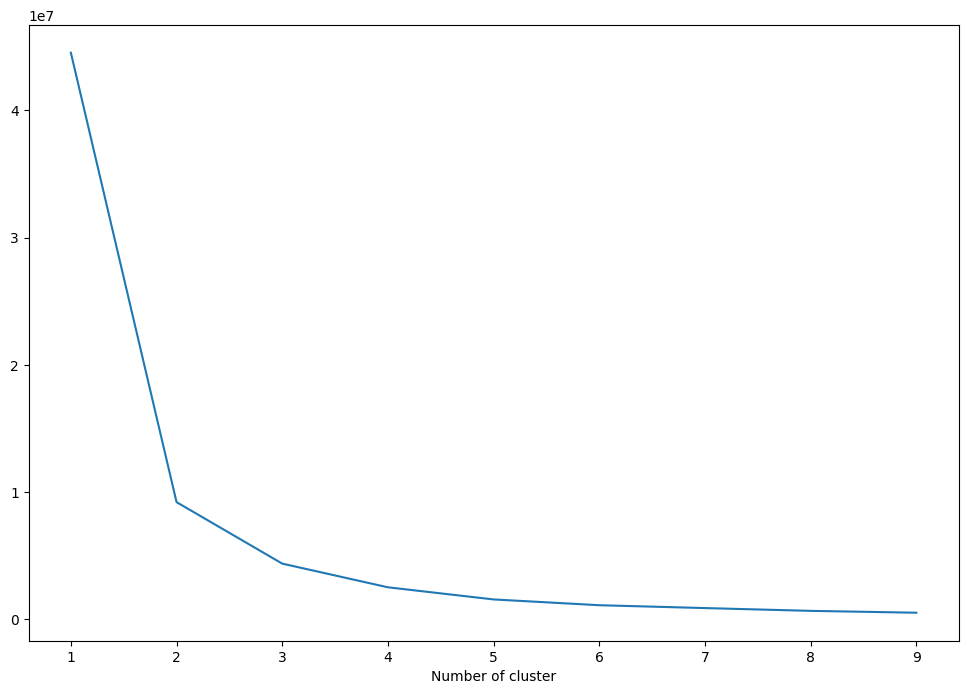

In [21]:
# Configuración inicial - Vamos a tomar como referencia el indicador de Recency
sse={}
recency = customer[['RECENCY']]

for k in range(1, 10):
    # Instancia el algoritmo de k-means iterando sobre k
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    # Entrena el algoritmo
    kmeans.fit(recency)
    
    # Adjunta las etiquetas
    recency["clusters"] = kmeans.labels_
    
    # Adunta la inercia o variación al arreglo sse
    sse[k] = kmeans.inertia_
    
# Grafico de codo (Elbow)
plt.figure(figsize=(12,8))
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of cluster")
plt.show()

In [22]:
# Instanciar el algoritmo con 4 clusters para Recency 
kmeans = KMeans(n_clusters=4, random_state=42)

# Entrenar el algoritmo
kmeans.fit(recency) 

# Obtener las predicciones
customer['RECENCY_CLUSTER'] = kmeans.labels_

# Ordenar los clusters
customer = order_cluster('RECENCY_CLUSTER', 'RECENCY', customer, False)

# Estadística Descriptiva del cluster creado
customer.groupby('RECENCY_CLUSTER')['RECENCY'].describe()

,count,mean,std,min,25%,50%,75%,max
RECENCY_CLUSTER,,,,,,,,
0,494.0,310.912955,38.940253,253.0,276.0,308.0,353.00,374.0
1,615.0,192.720325,32.608673,140.0,165.0,190.0,218.00,252.0
2,964.0,84.669087,23.930399,53.0,64.0,78.0,104.25,139.0
3,2299.0,19.423662,15.022921,0.0,7.0,17.0,30.00,52.0


In [23]:
# Instanciar el algoritmo con 4 clusters para Frequency 
kmeans = KMeans(n_clusters=4, random_state=42)

# Entrenar el algoritmo
kmeans.fit(customer[['FREQUENCY']])

# Obtener las predicciones
customer['FREQUENCY_CLUSTER'] = kmeans.labels_

# Ordenar los clusters
customer = order_cluster('FREQUENCY_CLUSTER', 'FREQUENCY', customer, True)

# Estadística Descriptiva de los clusters
customer.groupby('FREQUENCY_CLUSTER')['FREQUENCY'].describe()

,count,mean,std,min,25%,50%,75%,max
FREQUENCY_CLUSTER,,,,,,,,
0,3862.0,49.753755,44.812998,1.0,15.0,34.0,73.0,189.0
1,482.0,329.107884,132.670589,190.0,228.0,286.0,393.5,803.0
2,24.0,1349.750000,508.637759,872.0,1003.5,1156.0,1541.0,2782.0
3,4.0,5914.000000,1473.845537,4642.0,5006.5,5515.5,6423.0,7983.0


In [25]:
# Instanciar el algoritmo con 4 clusters para Monetary 
kmeans = KMeans(n_clusters=4, random_state=42)

# Entrenar el algoritmo
kmeans.fit(customer[['MONETARY']])

# Obtener las predicciones
customer['MONETARY_CLUSTER'] = kmeans.labels_

# Ordenar los clusters ¿Como tienes que ordenar el cluster?
customer = order_cluster('MONETARY_CLUSTER', 'MONETARY', customer, True)

# Estadística Descriptiva de los clusters
customer.groupby('MONETARY_CLUSTER')['MONETARY'].describe()

,count,mean,std,min,25%,50%,75%,max
MONETARY_CLUSTER,,,,,,,,
0,4329.0,1347.622983,1994.067733,-4287.63,291.0000,640.500,1550.8500,17588.26
1,36.0,35694.129167,14720.254051,18573.68,24695.2375,30800.450,50894.9825,65892.08
2,5.0,129057.952000,36658.292209,88125.38,113384.1400,123725.450,132572.6200,187482.17
3,2.0,267963.755000,16299.186073,256438.49,262201.1225,267963.755,273726.3875,279489.02


## Score de Segmentación
<p>El algoritmo de k-means nos da una segmentación generalizada, pero podemos personalizarla aún más creando una métrica que asigne una calificación al valor del cluster. Esto es lo que vamos a hacer!!</p>

In [26]:
# Vamos a crear nuestro score sumando el valor de cada uno de los clusters
customer['SCORE'] = customer['RECENCY_CLUSTER'] + customer['FREQUENCY_CLUSTER'] + customer['MONETARY_CLUSTER']

# Obtener el promedio para cada una de las métricas de las calificaciones creadas (Score)
customer.groupby('SCORE').mean()

,CUSTOMER_ID,INVOICE_DATE,RECENCY,FREQUENCY,MONETARY,RECENCY_CLUSTER,FREQUENCY_CLUSTER,MONETARY_CLUSTER
SCORE,,,,,,,,
0,15250.910569,2020-02-02 01:49:09.512195072,310.941057,22.380081,346.306179,0.000000,0.000000,0.000000
1,15438.996721,2020-05-29 16:35:38.655737856,193.326230,32.477049,536.167707,0.996721,0.003279,0.000000
2,15211.350802,2020-09-14 07:55:02.374331392,85.663102,45.690909,923.714622,1.992513,0.006417,0.001070
3,15300.291935,2020-11-16 14:50:46.258064640,22.393548,69.449462,1321.043167,2.980645,0.019355,0.000000
4,15376.598592,2020-11-26 07:27:27.464788736,12.741784,326.223005,5231.660329,3.000000,0.978873,0.021127
5,15078.647059,2020-12-01 20:35:22.941176320,7.176471,787.735294,21469.131471,3.000000,1.470588,0.529412
6,14383.285714,2020-12-02 19:31:34.285714176,6.142857,1383.714286,75232.314286,3.000000,1.714286,1.285714
7,15742.333333,2020-12-06 20:26:40.000000000,2.500000,3447.000000,97413.633333,3.000000,2.333333,1.666667
8,14778.500000,2020-12-08 14:03:00.000000000,0.500000,3994.000000,206030.820000,3.000000,2.500000,2.500000


In [28]:
# Crea una funcion que asigne lo siguiente: 
# Si score <= 1 entonces 'Low-Value', si score >1 y <=4 entonces 'Average', si score >4 y <=6 entonces 'Potential', por último si score >6 entonces 'High-Value'
def segment(score): 
    if score <= 1:
        return 'Low-Value'
    elif score > 1 and score <= 4:
        return 'Average'
    elif score > 4 and score <= 6:
        return 'Potential'
    else:
        return 'High-Value'


# Crear una columna aplicando esta función al campo 'SCORE'
customer['SEGMENT'] = customer['SCORE'].apply(segment)
customer

,CUSTOMER_ID,INVOICE_DATE,RECENCY,FREQUENCY,MONETARY,RECENCY_CLUSTER,FREQUENCY_CLUSTER,MONETARY_CLUSTER,SCORE,SEGMENT
0,13747.0,2019-12-01 10:37:00,374,1,79.60,0,0,0,0,Low-Value
1,12791.0,2019-12-01 11:27:00,374,2,192.60,0,0,0,0,Low-Value
2,16583.0,2019-12-01 12:03:00,374,14,233.45,0,0,0,0,Low-Value
3,14729.0,2019-12-01 12:43:00,374,71,313.49,0,0,0,0,Low-Value
4,18074.0,2019-12-01 09:53:00,374,13,489.60,0,0,0,0,Low-Value
...,...,...,...,...,...,...,...,...,...,...
4367,17405.0,2020-12-08 17:12:00,0,94,967.22,3,0,0,3,Average
4368,17389.0,2020-12-09 09:38:00,0,224,31300.08,3,1,1,5,Potential
4369,12526.0,2020-12-09 12:09:00,0,71,1316.66,3,0,0,3,Average
4370,12518.0,2020-12-09 10:13:00,0,124,2056.89,3,0,0,3,Average


In [29]:
# Vamos a dar un vistazo a la tabla final
customer.head()

,CUSTOMER_ID,INVOICE_DATE,RECENCY,FREQUENCY,MONETARY,RECENCY_CLUSTER,FREQUENCY_CLUSTER,MONETARY_CLUSTER,SCORE,SEGMENT
0,13747.0,2019-12-01 10:37:00,374,1,79.60,0,0,0,0,Low-Value
1,12791.0,2019-12-01 11:27:00,374,2,192.60,0,0,0,0,Low-Value
2,16583.0,2019-12-01 12:03:00,374,14,233.45,0,0,0,0,Low-Value
3,14729.0,2019-12-01 12:43:00,374,71,313.49,0,0,0,0,Low-Value
4,18074.0,2019-12-01 09:53:00,374,13,489.60,0,0,0,0,Low-Value


### Al crear un score RFM combinado (R + F + M) y clasificar a los clientes en 4 segmentos, se obtuvieron los siguientes grupos:
### Low-Value (Score ≤ 1): Clientes con poca actividad, compras esporádicas y bajo gasto. Representan el grupo con mayor riesgo de pérdida.
### Average (1 < Score ≤ 4): Clientes ocasionales con comportamiento promedio. Tienen potencial de crecimiento con estrategias adecuadas.
### Potential (4 < Score ≤ 6): Clientes prometedores que muestran buena actividad en al menos dos dimensiones. Son candidatos ideales para programas de fidelización.
### High-Value (Score > 6): Los mejores clientes con alta recurrencia, frecuencia y valor monetario. Requieren atención especial para retención.

In [30]:
# Imprime la proporción o el total de clientes por segmento
customer['SEGMENT'].value_counts(normalize=True)

SEGMENT
Average       0.736734
Low-Value     0.252059
Potential     0.009378
High-Value    0.001830
Name: proportion, dtype: float64

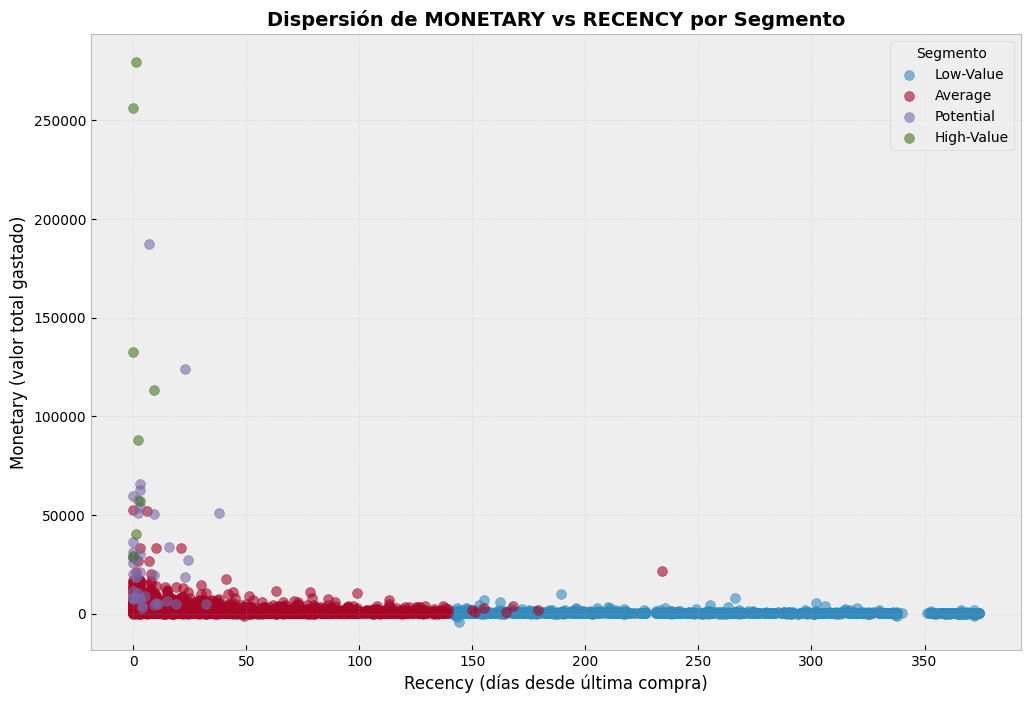

In [32]:
# Define un estilo 'bmh'
plt.style.use('bmh')

# Filtra los valores para RECENCY < 4000
customer_filtered = customer[customer['RECENCY'] < 4000]

# Crea un grafico de dispersion de 'MONETARY' VS 'RECENCY' por Segmento
plt.figure(figsize=(12, 8))
for segment in customer_filtered['SEGMENT'].unique():
    segment_data = customer_filtered[customer_filtered['SEGMENT'] == segment]
    plt.scatter(segment_data['RECENCY'], segment_data['MONETARY'], 
                label=segment, alpha=0.6, s=50)

plt.xlabel('Recency (días desde última compra)', fontsize=12)
plt.ylabel('Monetary (valor total gastado)', fontsize=12)
plt.title('Dispersión de MONETARY vs RECENCY por Segmento', fontsize=14, fontweight='bold')
plt.legend(title='Segmento')
plt.grid(True, alpha=0.3)
plt.show()

### Los clientes High-Value tienden a tener baja recency (compraron recientemente) y alto valor monetario
### Los clientes Low-Value muestran alta recency (no compran hace mucho) y bajo gasto
### Clara separación entre segmentos, validando la efectividad del modelo

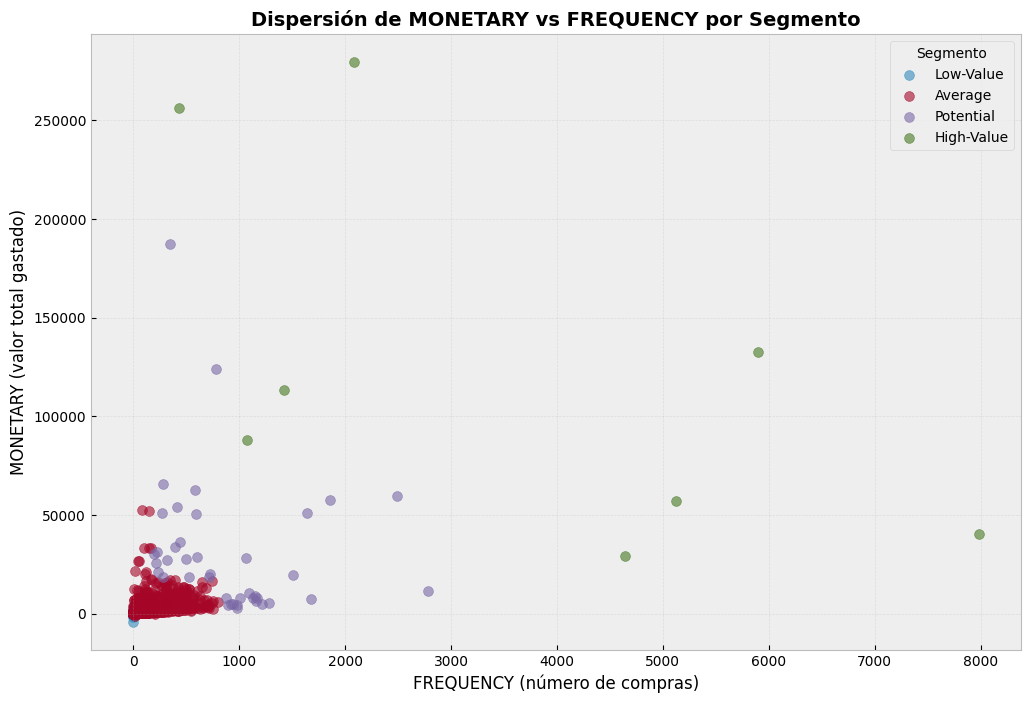

In [33]:
# Crea un grafico de dispersion de 'MONETARY' vs 'FREQUENCY' vs  por Segmento
plt.figure(figsize=(12, 8))
for segment in customer_filtered['SEGMENT'].unique():
    segment_data = customer_filtered[customer_filtered['SEGMENT'] == segment]
    plt.scatter(segment_data['FREQUENCY'], segment_data['MONETARY'], 
                label=segment, alpha=0.6, s=50)
plt.xlabel('FREQUENCY (número de compras)', fontsize=12)
plt.ylabel('MONETARY (valor total gastado)', fontsize=12)
plt.title('Dispersión de MONETARY vs FREQUENCY por Segmento', fontsize
=14, fontweight='bold')
plt.legend(title='Segmento')
plt.grid(True, alpha=0.3)
plt.show()





### Relación positiva fuerte: más compras = mayor gasto total
### Los clientes High-Value concentrados en alta frecuencia y alto gasto
### Algunos clientes Potential con alta frecuencia pero bajo valor unitario (oportunidad de upselling)

# Recomendaciones Estratégicas

### Retención de High-Value: Programas VIP, atención personalizada, descuentos exclusivos
### Activación de Potential: Campañas de cross-selling y aumentar ticket promedio
### Recuperación de Average: Email marketing con ofertas especiales para reactivar compras
### Win-back de Low-Value: Campañas agresivas de recuperación o evaluar costo-beneficio de retenerlos

### El análisis RFM demostró ser efectivo para segmentar la base de clientes y priorizar recursos de marketing hacia los segmentos más valiosos y con mayor potencial de crecimiento.